# Phase 2 Step 3 — Temporal stability, naming, and operational contract

Objective: test whether the frozen KMeans-3 behavioral structure re-emerges at June–September month ends, align arbitrary labels without future outcomes, quantify movement, and define semantic and operational contracts.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT/'src'))
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from marketmind.segmentation.snapshot import build_household_snapshot
from marketmind.segmentation.preprocessing import FINAL_FEATURES, prepare_features, apply_preprocessor
from marketmind.segmentation.alignment import relative_profile_signatures, align_to_reference, remap_labels, semantic_mapping_from_profiles
RAW=ROOT/'data'/'raw'/'complete_journey'; FIGURES=ROOT/'reports'/'segmentation'/'figures'; ARTIFACTS=ROOT/'reports'/'segmentation'/'artifacts'
FIGURES.mkdir(parents=True,exist_ok=True); ARTIFACTS.mkdir(parents=True,exist_ok=True)

## Frozen methodology and temporal snapshots
Each snapshot uses the unchanged eligibility, nine ordered features, four `log1p` transformations, snapshot-fitted RobustScaler, and `KMeans(n_clusters=3, n_init=20, random_state=42)`. The exact month ends are June 30, July 31, August 31, and September 30, all at 23:59:59.

In [2]:
transactions=pyreadr.read_r(str(RAW/'transactions.rds'))[None]; products=pyreadr.read_r(str(RAW/'products.rda'))['products']
dates=['2017-06-30 23:59:59','2017-07-31 23:59:59','2017-08-31 23:59:59','2017-09-30 23:59:59']
runs={}; metric_rows=[]
for date in dates:
    snapshot=build_household_snapshot(transactions,products,snapshot_at=date)
    assert snapshot.features.index.is_unique and not snapshot.features[list(FINAL_FEATURES)].isna().any().any()
    assert transactions.loc[transactions.transaction_timestamp<=pd.Timestamp(date),'transaction_timestamp'].max()<=pd.Timestamp(date)
    prepared=prepare_features(snapshot.features); model=KMeans(n_clusters=3,n_init=20,random_state=42).fit(prepared.scaled); labels=model.labels_
    counts=pd.Series(labels).value_counts().sort_index()
    runs[date]={'snapshot':snapshot,'prepared':prepared,'model':model,'raw_labels':labels,'signature':relative_profile_signatures(snapshot.features,labels)}
    metric_rows.append({'snapshot':date,'eligible_households':len(labels),'silhouette':silhouette_score(prepared.scaled,labels),'davies_bouldin':davies_bouldin_score(prepared.scaled,labels),'calinski_harabasz':calinski_harabasz_score(prepared.scaled,labels),'raw_counts':json.dumps(counts.to_dict())})
metrics=pd.DataFrame(metric_rows); metrics.to_csv(ARTIFACTS/'temporal_snapshot_metrics.csv',index=False); display(metrics)

,snapshot,eligible_households,silhouette,davies_bouldin,calinski_harabasz,raw_counts
0,2017-06-30 23:59:59,2085,0.206886,1.530205,548.299431,"{""0"": 997, ""1"": 230, ""2"": 858}"
1,2017-07-31 23:59:59,2172,0.203833,1.566777,536.743263,"{""0"": 880, ""1"": 1066, ""2"": 226}"
2,2017-08-31 23:59:59,2219,0.203451,1.574615,539.413467,"{""0"": 257, ""1"": 1077, ""2"": 885}"
3,2017-09-30 23:59:59,2247,0.203128,1.564733,559.685496,"{""0"": 293, ""1"": 1077, ""2"": 877}"


## Independent fitting and cluster alignment
Raw IDs are never compared directly. Each cluster's original-unit median profile is expressed relative to that snapshot's household median and IQR. Hungarian assignment minimizes total Euclidean distance between this relative profile signature and the September reference signatures. This preserves independent fitting and aligns behavioral meaning rather than integer labels.

In [3]:
reference=runs[dates[-1]]; alignment_rows=[]; profile_rows=[]
for date in dates:
    mapping,distance_matrix=align_to_reference(runs[date]['signature'],reference['signature'])
    aligned=remap_labels(runs[date]['raw_labels'],mapping); runs[date]['mapping']=mapping; runs[date]['aligned_labels']=aligned
    for raw,reference_id in mapping.items(): alignment_rows.append({'snapshot':date,'raw_cluster_id':raw,'aligned_reference_id':reference_id,'profile_distance_to_reference':distance_matrix.loc[raw,reference_id]})
    grouped=runs[date]['snapshot'].features.assign(aligned_cluster=aligned).groupby('aligned_cluster')
    medians=grouped[list(FINAL_FEATURES)].median(); counts=grouped.size()
    for cluster,row in medians.iterrows(): profile_rows.append({'snapshot':date,'aligned_cluster':cluster,'household_count':counts[cluster],'household_share':counts[cluster]/len(aligned),**row.to_dict()})
alignment=pd.DataFrame(alignment_rows); profiles=pd.DataFrame(profile_rows)
alignment.to_csv(ARTIFACTS/'temporal_cluster_alignment.csv',index=False); profiles.to_csv(ARTIFACTS/'temporal_aligned_profiles.csv',index=False)
display(alignment); display(profiles)

,snapshot,raw_cluster_id,aligned_reference_id,profile_distance_to_reference
0,2017-06-30 23:59:59,0,1,0.158486
1,2017-06-30 23:59:59,1,0,0.578983
2,2017-06-30 23:59:59,2,2,0.182514
3,2017-07-31 23:59:59,0,2,0.091505
4,2017-07-31 23:59:59,1,1,0.078956
5,2017-07-31 23:59:59,2,0,0.471077
6,2017-08-31 23:59:59,0,0,0.245292
7,2017-08-31 23:59:59,1,1,0.043328
8,2017-08-31 23:59:59,2,2,0.226427
9,2017-09-30 23:59:59,0,0,0.000000


,snapshot,aligned_cluster,household_count,household_share,recency_days,basket_frequency,monetary_value,avg_basket_value,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,private_label_spend_share
0,2017-06-30 23:59:59,0,230,0.110312,4.0,25.0,1057.365,42.573544,11.0,0.348296,0.190155,0.245299,0.237515
1,2017-06-30 23:59:59,1,997,0.478177,2.0,42.0,1309.210,30.481546,12.0,0.313374,0.142498,0.033333,0.274914
2,2017-06-30 23:59:59,2,858,0.411511,11.0,13.0,287.620,20.042000,7.0,0.391241,0.150424,0.000000,0.254169
3,2017-07-31 23:59:59,0,226,0.104052,4.0,27.0,1130.270,44.993755,11.0,0.350162,0.190827,0.246795,0.238986
4,2017-07-31 23:59:59,1,1066,0.490792,2.0,48.0,1482.570,30.263143,12.0,0.310416,0.144548,0.033473,0.277533
5,2017-07-31 23:59:59,2,880,0.405157,11.0,14.0,316.455,20.348333,7.0,0.384673,0.149221,0.000000,0.248851
6,2017-08-31 23:59:59,0,257,0.115818,5.0,32.0,1331.920,43.588462,11.0,0.345004,0.192318,0.222222,0.247146
7,2017-08-31 23:59:59,1,1077,0.485354,2.0,55.0,1624.050,29.783478,12.0,0.308955,0.142565,0.032258,0.279889
8,2017-08-31 23:59:59,2,885,0.398828,13.0,15.0,345.220,20.572667,8.0,0.377451,0.150211,0.000000,0.244681
9,2017-09-30 23:59:59,0,293,0.130396,5.0,34.0,1412.950,43.322500,11.0,0.348738,0.194658,0.214286,0.239595


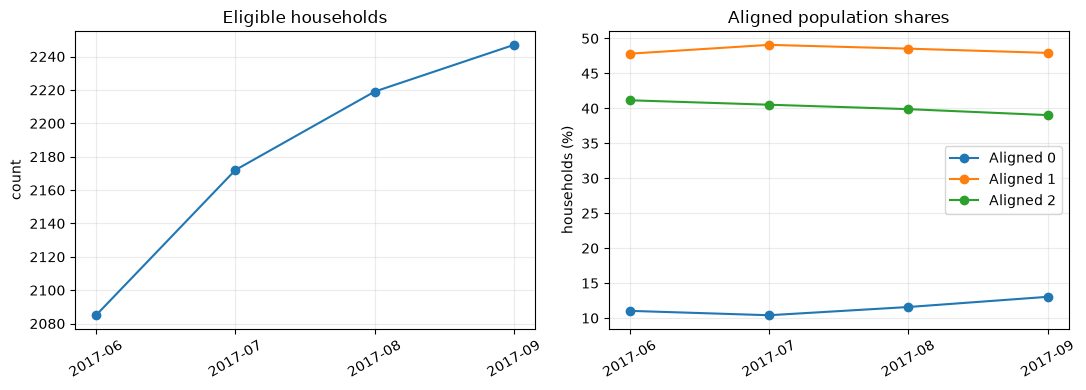

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(metrics.snapshot.str[:7],metrics.eligible_households,marker='o'); axes[0].set_title('Eligible households'); axes[0].set_ylabel('count')
for cluster,group in profiles.groupby('aligned_cluster'): axes[1].plot(group.snapshot.str[:7],100*group.household_share,marker='o',label=f'Aligned {cluster}')
axes[1].set_title('Aligned population shares'); axes[1].set_ylabel('households (%)'); axes[1].legend()
for ax in axes: ax.tick_params(axis='x',rotation=30); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES/'temporal_population_stability.png',dpi=160); plt.show()

## Household migration
For households eligible in consecutive snapshots, ARI and transition rates combine genuine accumulated behavior with changes in independently fitted geometry. They are not pure model-seed stability metrics.

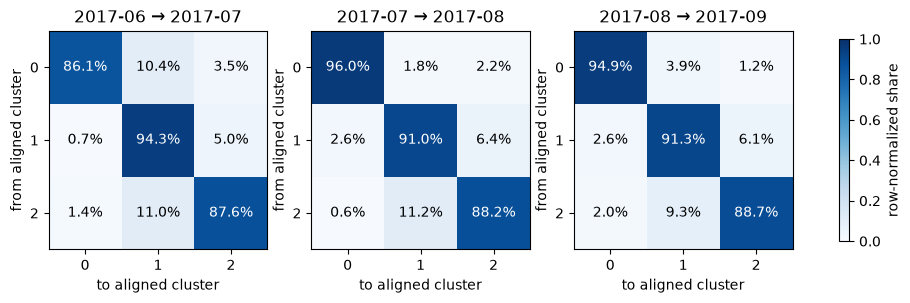

,from_snapshot,to_snapshot,common_households,unchanged_share,moved_share,ari
0,2017-06-30 23:59:59,2017-07-31 23:59:59,2085,0.906475,0.093525,0.713304
1,2017-07-31 23:59:59,2017-08-31 23:59:59,2172,0.903775,0.096225,0.700084
2,2017-08-31 23:59:59,2017-09-30 23:59:59,2219,0.906715,0.093285,0.717459


In [5]:
transition_rows=[]; transition_cells=[]
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,(left,right) in zip(axes,zip(dates,dates[1:])):
    a=pd.Series(runs[left]['aligned_labels'],index=runs[left]['snapshot'].features.index,name='from'); b=pd.Series(runs[right]['aligned_labels'],index=runs[right]['snapshot'].features.index,name='to'); common=a.index.intersection(b.index); a=a.loc[common]; b=b.loc[common]
    matrix=pd.crosstab(a,b).reindex(index=[0,1,2],columns=[0,1,2],fill_value=0); normalized=matrix.div(matrix.sum(axis=1),axis=0)
    unchanged=(a.to_numpy()==b.to_numpy()).mean(); ari=adjusted_rand_score(a,b)
    transition_rows.append({'from_snapshot':left,'to_snapshot':right,'common_households':len(common),'unchanged_share':unchanged,'moved_share':1-unchanged,'ari':ari})
    for i in matrix.index:
        for j in matrix.columns: transition_cells.append({'from_snapshot':left,'to_snapshot':right,'from_cluster':i,'to_cluster':j,'count':matrix.loc[i,j],'row_share':normalized.loc[i,j]})
    image=ax.imshow(normalized,vmin=0,vmax=1,cmap='Blues'); ax.set_title(f'{left[:7]} → {right[:7]}'); ax.set(xlabel='to aligned cluster',ylabel='from aligned cluster'); ax.set_xticks(range(3)); ax.set_yticks(range(3))
    for i in range(3):
        for j in range(3): ax.text(j,i,f'{normalized.loc[i,j]:.1%}',ha='center',va='center',color='white' if normalized.loc[i,j]>.55 else 'black')
transitions=pd.DataFrame(transition_rows); transition_detail=pd.DataFrame(transition_cells)
transitions.to_csv(ARTIFACTS/'temporal_transition_summary.csv',index=False); transition_detail.to_csv(ARTIFACTS/'temporal_transition_matrices.csv',index=False)
fig.colorbar(image,ax=axes.ravel().tolist(),shrink=.75,label='row-normalized share'); fig.savefig(FIGURES/'temporal_transition_matrices.png',dpi=160,bbox_inches='tight'); plt.show(); display(transitions)

## Reference-model assignment sensitivity
Earlier features are separately passed through the fitted September scaler and centroids. This is a centroid-consistency diagnostic, not a historical deployment simulation, and is kept distinct from independent temporal fits.

In [6]:
sensitivity=[]
for date in dates[:-1]:
    fixed_scaled=apply_preprocessor(runs[date]['snapshot'].features,reference['prepared'].scaler); fixed=reference['model'].predict(fixed_scaled); independent=runs[date]['aligned_labels']
    sensitivity.append({'snapshot':date,'households':len(fixed),'agreement_with_independent_fit':np.mean(fixed==independent),'ari_with_independent_fit':adjusted_rand_score(fixed,independent),'fixed_assignment_counts':json.dumps(pd.Series(fixed).value_counts().sort_index().to_dict())})
sensitivity=pd.DataFrame(sensitivity); sensitivity.to_csv(ARTIFACTS/'reference_assignment_sensitivity.csv',index=False); display(sensitivity)

,snapshot,households,agreement_with_independent_fit,ari_with_independent_fit,fixed_assignment_counts
0,2017-06-30 23:59:59,2085,0.904556,0.706135,"{""0"": 276, ""1"": 806, ""2"": 1003}"
1,2017-07-31 23:59:59,2172,0.932781,0.792299,"{""0"": 273, ""1"": 925, ""2"": 974}"
2,2017-08-31 23:59:59,2219,0.954033,0.852853,"{""0"": 281, ""1"": 996, ""2"": 942}"


## Profile stability and naming review
Semantic names are derived from September behavior, not raw IDs: the most frequent profile is high-engagement/broad; among the remainder, the highest coupon-use profile is promotion-oriented; the remaining profile is lower-engagement/focused. Across all months the relative ordering and behavioral meanings remain recognizable.

{1: SegmentDefinition(segment_code='HIGH_ENGAGEMENT_BROAD', display_name='High-Engagement Broad Shoppers', description='Recent, frequent, high-spend households purchasing across a broad assortment.'), 0: SegmentDefinition(segment_code='PROMOTION_BASKET_BUILDERS', display_name='Promotion-Oriented Basket Builders', description='Moderate-frequency households with larger baskets and stronger observed discount/coupon use.'), 2: SegmentDefinition(segment_code='LOWER_ENGAGEMENT_FOCUSED', display_name='Lower-Engagement Focused Shoppers', description='Less-recent, lower-frequency and lower-spend households with narrower assortments.')}


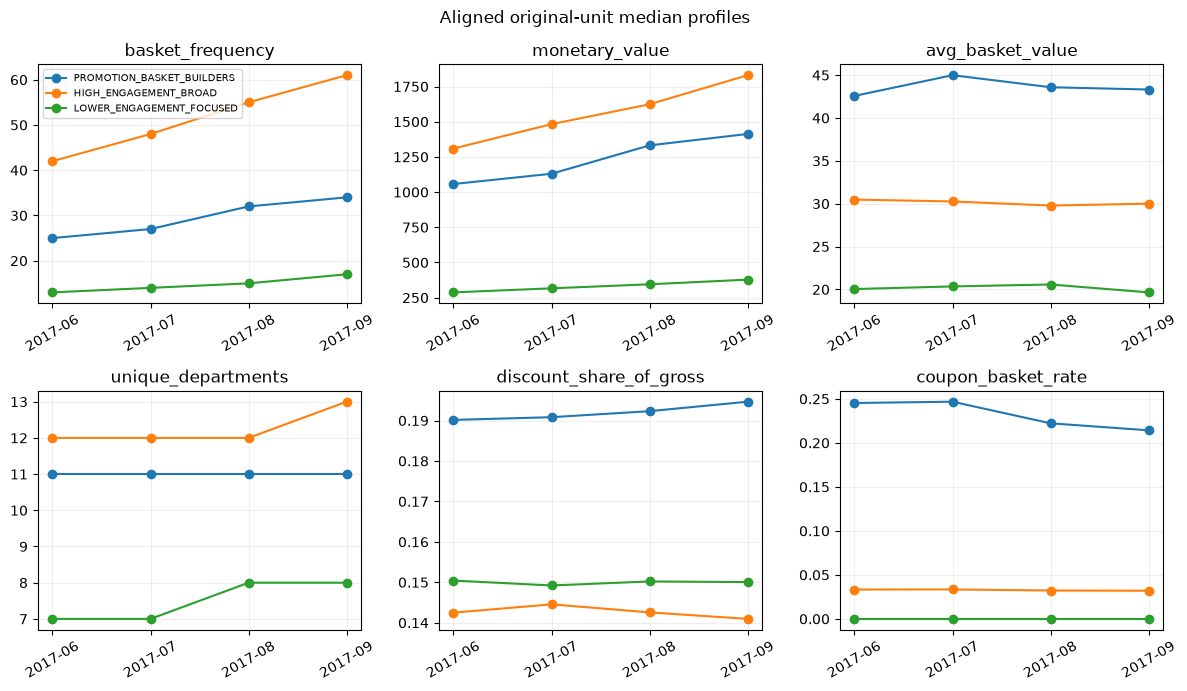

In [7]:
reference_profiles=reference['snapshot'].features.assign(cluster=reference['raw_labels']).groupby('cluster').median(numeric_only=True); semantic=semantic_mapping_from_profiles(reference_profiles); print({k:v for k,v in semantic.items()})
plot_features=['basket_frequency','monetary_value','avg_basket_value','unique_departments','discount_share_of_gross','coupon_basket_rate']
fig,axes=plt.subplots(2,3,figsize=(12,7))
for ax,feature in zip(axes.flat,plot_features):
    for cluster,group in profiles.groupby('aligned_cluster'): ax.plot(group.snapshot.str[:7],group[feature],marker='o',label=semantic[cluster].segment_code); ax.set_title(feature); ax.tick_params(axis='x',rotation=30); ax.grid(alpha=.2)
axes[0,0].legend(fontsize=7); fig.suptitle('Aligned original-unit median profiles'); fig.tight_layout(); fig.savefig(FIGURES/'temporal_profile_stability.png',dpi=160); plt.show()

## Operational implications and decision
The three-group structure is temporally credible under the predeclared policy. Raw `cluster_id` is model-specific; the stable contract is `segment_code`, display name, and behavioral description. Eligible households are transformed with the fitted pipeline and assigned to the nearest centroid. Distance is geometric atypicality, not probability/confidence. Ineligible households receive `insufficient_history`, not a fourth segment. Recommend monthly eligibility/assignment refresh and quarterly model review; refit only after sustained, multi-signal drift or loss of profile meaning. No model is serialized here.